<a href="https://colab.research.google.com/github/limkc0116/FYP/blob/main/CNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2: Import Libraries

In [ ]:
# Cell 2 — Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import os

## Cell 3: Define Dataset Paths

In [ ]:
# Cell 3 — Paths
dataset_path = "/content/drive/MyDrive/FYPCNN/FYP-3-74"

train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

## Cell 4: Setup Data Generators and Class Weights

In [ ]:
# Cell 4 — Data Generators (FIXED: add class_weight to handle imbalance)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

img_size   = (224, 224)
batch_size = 20

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
valid_generator = valid_datagen.flow_from_directory(
    valid_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# ✅ Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

Found 3842 images belonging to 6 classes.
Found 550 images belonging to 6 classes.
Found 273 images belonging to 6 classes.
Class Weights: {0: np.float64(0.7360153256704981), 1: np.float64(0.7733494363929146), 2: np.float64(1.6008333333333333), 3: np.float64(4.104700854700854), 4: np.float64(1.1155632984901278), 5: np.float64(0.6314924391847468)}


In [ ]:
import os

# Check for Data Leakage: Ensure no image filenames are shared between splits
train_files = set(os.listdir(os.path.join(train_dir, 'Eat_or_Drink'))) # Example class
test_files = set(os.listdir(os.path.join(test_dir, 'Eat_or_Drink')))

overlap = train_files.intersection(test_files)
if overlap:
    print(f"⚠️ ALERT: Found {len(overlap)} overlapping files. Your model might be 'memorizing' test images.")
else:
    print("✅ No filename overlap detected in sample class.")

✅ No filename overlap detected in sample class.


### Making the System More Robust
To bring the results closer to 'real-world' expectations and prevent potential overfitting, we can:
1. **Increase Augmentation**: Make it harder for the model by adding more extreme rotations and brightness shifts.
2. **Increase Dropout**: Force the model to learn more distributed features.

In [ ]:
# Modified Data Generator with more aggressive augmentation
train_datagen_robust = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Increased from 10
    width_shift_range=0.2,   # Increased from 0.1
    height_shift_range=0.2,  # Increased from 0.1
    brightness_range=[0.7, 1.3], # Handle different lighting
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Re-run the flow_from_directory using this robust generator
train_generator = train_datagen_robust.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

Found 3842 images belonging to 6 classes.


## Cell 5: Build Initial Convolutional Neural Network (CNN) Model

In [ ]:
# Cell 5 — Build Model
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,793,382 (10.66 MB)

 Trainable params: 2,793,158 (10.66 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.regularizers import l2

# Re-building with stronger regularization to prevent 99% 'memorization'
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)), # Added L2 Regularization
    BatchNormalization(),
    Dropout(0.6), # Increased Dropout from 0.5
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,124,550 (92.03 MB)

 Trainable params: 558,982 (2.13 MB)

 Non-trainable params: 23,565,568 (89.90 MB)

### Custom CNN Architecture (No ResNet)
This model is built from scratch. It uses standard Convolutional layers to learn spatial features specifically from your driving dataset.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Building a deeper custom CNN
custom_model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Fully Connected
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

custom_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,994,758 (19.05 MB)

 Trainable params: 4,994,054 (19.05 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks here so they are available

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

print("🚀 Training Custom CNN...")
custom_history = custom_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

# Save the custom model
custom_save_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/custom_cnn_model.keras'
custom_model.save(custom_save_path)
print(f"✅ Custom CNN saved to: {custom_save_path}")

🚀 Training Custom CNN...
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 98s 469ms/step - accuracy: 0.1281 - loss: 7.8908 - val_accuracy: 0.0400 - val_loss: 1.7922 - learning_rate: 0.0100
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 84s 432ms/step - accuracy: 0.1517 - loss: 1.8529 - val_accuracy: 0.2164 - val_loss: 1.7966 - learning_rate: 0.0100
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 84s 437ms/step - accuracy: 0.1218 - loss: 1.8008 - val_accuracy: 0.2182 - val_loss: 1.7779 - learning_rate: 0.0100
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 85s 440ms/step - accuracy: 0.2311 - loss: 1.8056 - val_accuracy: 0.1909 - val_loss: 1.7201 - learning_rate: 0.0100
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 432ms/step - accuracy: 0.1486 - loss: 1.8709 - val_accuracy: 0.1055 - val_loss: 1.7981 - learning_rate: 0.0100
Epoch 6/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 430ms/step - accuracy: 0.1273 - loss: 1.8024 - val_accuracy: 0.0382 - val_loss: 1.8019 - learning_rate: 0.0100
Epoch 7/100
193/193 ━━━━━━━━━━━━━━━━━━━

## Cell 12: Evaluate the Custom CNN Model

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# 1. Path to your saved custom CNN model
saved_cnn_model_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/custom_cnn_model.keras'

print(f"📂 Loading custom CNN model from: {saved_cnn_model_path}...")
custom_model_loaded = load_model(saved_cnn_model_path)

# 2. Setup Validation Data (550 images) - ensure it matches the training setup
img_size = (224, 224)
batch_size = 20

valid_datagen_eval = ImageDataGenerator(rescale=1./255)
valid_generator_eval = valid_datagen_eval.flow_from_directory(
    '/content/drive/MyDrive/FYPCNN/FYP-3-74/valid', # Use the correct validation directory
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true_cnn = valid_generator_eval.classes
class_names_cnn = list(valid_generator_eval.class_indices.keys())

# 3. Predict on Validation Set
print(f"🔍 Predicting on VALIDATION set for Custom CNN ({len(y_true_cnn)} images)...")
preds_cnn = custom_model_loaded.predict(valid_generator_eval)
y_pred_cnn = np.argmax(preds_cnn, axis=1)

# 4. Show Results
print("\n--- CUSTOM CNN VALIDATION SET PERFORMANCE ---")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names_cnn))
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
print("Custom CNN Validation Confusion Matrix:\n", cm_cnn)


📂 Loading custom CNN model from: /content/drive/MyDrive/FYPCNN/FYP-3-74/custom_cnn_model.keras...
Found 550 images belonging to 6 classes.
🔍 Predicting on VALIDATION set for Custom CNN (550 images)...
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step

--- CUSTOM CNN VALIDATION SET PERFORMANCE ---
                precision    recall  f1-score   support

Center_Console       0.00      0.00      0.00       120
  Eat_or_Drink       0.00      0.00      0.00       119
    Glove_Open       1.00      0.34      0.51        58
      Hand_Off       0.00      0.00      0.00        21
    Mirror_adj       0.16      1.00      0.28        85
     Phone_Use       0.00      0.00      0.00       147

      accuracy                           0.19       550
     macro avg       0.19      0.22      0.13       550
  weighted avg       0.13      0.19      0.10       550

Custom CNN Validation Confusion Matrix:
 [[  0   0   0   0 120   0]
 [  0   0   0   0 119   0]
 [  0   0  20   0  38   0]
 [  0   0   0   0  21   0]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Cell 13: Compile Transfer Learning Model

In [ ]:
# Cell 13 — Compile the new model with the requested learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Cell 14: Train the Transfer Learning Model (ResNet50V2)

🚀 Starting training with LR=0.001 and Max Epochs=100...
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 107s 492ms/step - accuracy: 0.6822 - loss: 1.2864 - val_accuracy: 0.9400 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 85s 439ms/step - accuracy: 0.8058 - loss: 0.9172 - val_accuracy: 0.9491 - val_loss: 0.6382 - learning_rate: 0.0010
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 428ms/step - accuracy: 0.8384 - loss: 0.8103 - val_accuracy: 0.9255 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 81s 419ms/step - accuracy: 0.8376 - loss: 0.7679 - val_accuracy: 0.9327 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 430ms/step - accuracy: 0.8438 - loss: 0.7141 - val_accuracy: 0.9164 - val_loss: 0.5693 - learning_rate: 0.0010
Epoch 6/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 426ms/step - accuracy: 0.8670 - loss: 0.6651 - val_accuracy: 0.9564 - val_loss: 0.4951 - learning_rate: 0.0010
Epoch 7

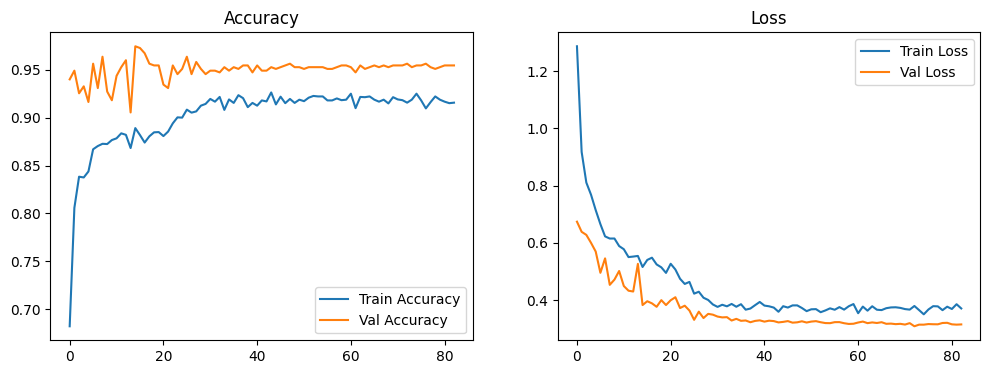

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Standardizing the initial learning rate to 0.001 for better stability
initial_lr = 0.001
epochs = 100

# 2. Setup robust callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# 3. Re-compile
model.compile(
    optimizer=Adam(learning_rate=initial_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"🚀 Starting training with LR={initial_lr} and Max Epochs={epochs}...")
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

# 4. Save the model
save_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/robust_resnet_model.keras'
model.save(save_path)
print(f"✅ Improved model saved to: {save_path}")

# 5. Plot training history to see improvement
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

## Cell 15: Evaluate the New Model

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# 1. Path to your high-performing saved model
save_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/robust_resnet_model.keras' # Corrected path to load the saved ResNet model

print(f"📂 Loading model from: {save_path}...")
model = load_model(save_path)

# 2. Setup Validation Data (550 images)
valid_datagen = ImageDataGenerator(rescale=1./255)
img_size = (224, 224)
batch_size = 20
# Changed from test to valid as requested
valid_dir = '/content/drive/MyDrive/FYPCNN/FYP-3-74/valid'

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = valid_generator.classes
class_names = list(valid_generator.class_indices.keys())

# 3. Predict on Validation Set
print(f"🔍 Predicting on VALIDATION set ({len(y_true)} images)...")
preds = model.predict(valid_generator)
y_pred = np.argmax(preds, axis=1)

# 4. Show Results
print("\n--- VALIDATION SET PERFORMANCE (550 IMAGES) ---")
print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
print("Validation Confusion Matrix:\n", cm)

📂 Loading model from: /content/drive/MyDrive/FYPCNN/FYP-3-74/robust_resnet_model.keras...
Found 550 images belonging to 6 classes.
🔍 Predicting on VALIDATION set (550 images)...
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step

--- VALIDATION SET PERFORMANCE (550 IMAGES) ---
                precision    recall  f1-score   support

Center_Console       0.99      0.89      0.94       120
  Eat_or_Drink       0.96      0.97      0.96       119
    Glove_Open       1.00      1.00      1.00        58
      Hand_Off       0.58      1.00      0.74        21
    Mirror_adj       1.00      1.00      1.00        85
     Phone_Use       0.98      0.95      0.97       147

      accuracy                           0.96       550
     macro avg       0.92      0.97      0.93       550
  weighted avg       0.97      0.96      0.96       550

Validation Confusion Matrix:
 [[107   0   0  13   0   0]
 [  0 115   0   1   0   3]
 [  0   0  58   0   0   0]
 [  0   0   0  21   0   0]
 [  0   0   0   0  85   0]
 [ 

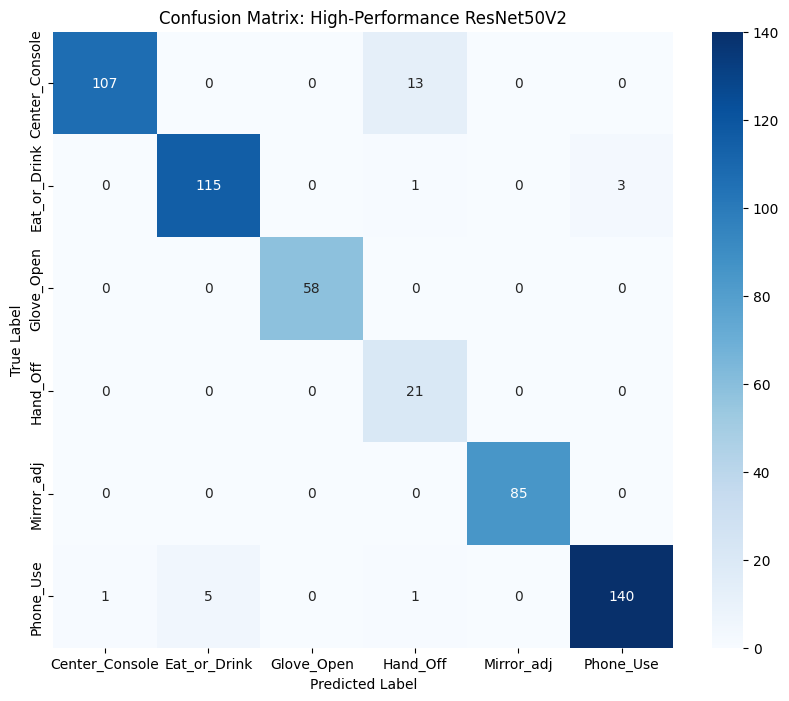

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the correct high-performance confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, # Using the 'cm' variable from the latest evaluation cell
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix: High-Performance ResNet50V2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Optional: Fine-Tuning the Base Model
Instead of changing the learning rate, we can change **how many layers** are allowed to learn. Unfreezing the final block of ResNet50V2 allows the model to specialize its internal filters to the specific geometry of a car interior.

In [ ]:
import cv2
import numpy as np
import gc
import os
from tensorflow.keras.models import load_model

# 1. Updated Paths for the best ResNet50V2 model
model_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/robust_resnet_model.keras'
video_path = '/content/drive/MyDrive/FYPCNN/3_car.mp4'
output_path = '/content/drive/MyDrive/FYPCNN/FYP-3-74/final_ResNet_detection_size.mp4'
img_size = (224, 224)
classes = ['Center_Console', 'Eat_or_Drink', 'Glove_Open', 'Hand_Off', 'Mirror_adj', 'Phone_Use']

# 2. Load the High-Performance Model
try:
    cnn_model = load_model(model_path)
    print(f"✅ ResNet50V2 Model loaded successfully from {model_path}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    cnn_model = None

if cnn_model:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Error: Could not open video file.")
    else:
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
        w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

        distraction_frames = 0
        empty_frames_count = 0
        grace_period_frames = int(0.5 * fps)
        frame_count = 0

        print(f"🚀 Starting video processing...")

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            img_resized = cv2.resize(frame, img_size)
            img_normalized = img_resized / 255.0
            img_batch = np.expand_dims(img_normalized, axis=0)

            preds = cnn_model.predict(img_batch, verbose=0)[0]
            class_idx = np.argmax(preds)
            conf = preds[class_idx]
            class_name = classes[class_idx]

            # Logic: Distraction includes Phone, Eating, and Hands off wheel
            is_distracted = (class_name in ['Hand_Off', 'Phone_Use', 'Eat_or_Drink']) and (conf > 0.4)

            if is_distracted:
                distraction_frames += 1
                empty_frames_count = 0
            else:
                empty_frames_count += 1
                if empty_frames_count > grace_period_frames:
                    distraction_frames = 0

            elapsed_time = distraction_frames / fps

            # Annotate Frame
            # Activity text: changed from green to black, increased font size
            cv2.putText(frame, f"Activity: {class_name} ({conf*100:.1f}%)", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 2)

            if distraction_frames > 0:
                timer_text = f"Distraction Timer: {elapsed_time:.1f}s"
                color = (0, 140, 255) # Dark Orange (BGR)
                if elapsed_time >= 4.0:
                    color = (0, 0, 255) # Red
                    # Increased font size for alert
                    cv2.putText(frame, "!!! DISTRACTED ALERT !!!", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.8, color, 3)
                elif elapsed_time >= 2.0:
                    # Increased font size for warning
                    cv2.putText(frame, "WARNING: STAY FOCUSED", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 2)

                cv2.putText(frame, timer_text, (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 2)

            out.write(frame)
            frame_count += 1
            if frame_count % 100 == 0: print(f"Processed {frame_count} frames...")

        cap.release()
        out.release()
        print(f"✅ Video processing complete! Saved to: {output_path}")

✅ ResNet50V2 Model loaded successfully from /content/drive/MyDrive/FYPCNN/FYP-3-74/robust_resnet_model.keras
🚀 Starting video processing...
Processed 100 frames...
Processed 200 frames...
Processed 300 frames...
Processed 400 frames...
Processed 500 frames...
Processed 600 frames...
Processed 700 frames...
Processed 800 frames...
Processed 900 frames...
Processed 1000 frames...
Processed 1100 frames...
Processed 1200 frames...
Processed 1300 frames...
Processed 1400 frames...
Processed 1500 frames...
Processed 1600 frames...
Processed 1700 frames...
Processed 1800 frames...
Processed 1900 frames...
Processed 2000 frames...
Processed 2100 frames...
Processed 2200 frames...
Processed 2300 frames...
Processed 2400 frames...
Processed 2500 frames...
Processed 2600 frames...
Processed 2700 frames...
Processed 2800 frames...
Processed 2900 frames...
Processed 3000 frames...
Processed 3100 frames...
Processed 3200 frames...
Processed 3300 frames...
Processed 3400 frames...
Processed 3500 fram